<a href="https://colab.research.google.com/github/Venu-max/NASSCOM-AI/blob/main/Day4_U10_%E2%80%94_Feature_Engineering_(Part_1)_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# === SETUP: load the provided data files (regenerate them if missing) ===
import os
import numpy as np
import pandas as pd

def build_datasets(csv_path='ecommerce_customers.csv',
                   xlsx_path='transactions.xlsx', seed=42, verbose=False):
    """Generate a realistic e-commerce customer + transactions dataset.

    Baked-in realism for EDA / feature engineering practice:
      - right-skewed monetary columns (total_spend) with a few 'whale' outliers
      - class imbalance in is_churned (~20-30%)
      - real signal: churn depends on recency, order count and support tickets
      - missing values in age / gender / city
      - a high-cardinality 'city' column (long tail of rare cities)
      - customers with zero orders (no last_order_date) -> dormant
    The Excel file is order-level and is CONSISTENT with the customer table
    (num_orders / total_spend / last_order_date are derived from it).
    """
    rng = np.random.default_rng(seed)
    N = 2500
    start = pd.Timestamp('2021-01-01')
    end = pd.Timestamp('2024-06-30')
    horizon = (end - start).days

    cust = np.array([f'CUST{i+1:05d}' for i in range(N)])
    signup_off = rng.integers(0, horizon - 60, N)
    signup = start + pd.to_timedelta(signup_off, unit='D')

    # order counts: overdispersed (gamma-poisson), some customers have zero
    lam = rng.gamma(2.0, 1.6, N)
    num_orders = rng.poisson(lam)

    # ---- order-level transactions (vectorised) ----
    counts = num_orders
    tot = int(counts.sum())
    cust_rep = np.repeat(cust, counts)
    signup_rep = np.repeat(signup_off, counts)
    span = np.maximum(horizon - signup_off, 1)
    span_rep = np.repeat(span, counts)
    off = (rng.random(tot) * span_rep).astype(int)
    tx_off = signup_rep + off
    tx_date = start + pd.to_timedelta(tx_off, unit='D')
    amount = rng.lognormal(3.2, 0.8, tot).round(2)        # right-skewed (~tens of currency)
    category = rng.choice(['Electronics', 'Fashion', 'Grocery', 'Home', 'Books'],
                          tot, p=[.20, .30, .25, .15, .10])
    tx = pd.DataFrame({'customer_id': cust_rep, 'order_date': tx_date,
                       'amount': amount, 'category': category}).sort_values(
        ['customer_id', 'order_date']).reset_index(drop=True)

    # ---- aggregate transactions -> customer level ----
    agg = tx.groupby('customer_id').agg(
        total_spend=('amount', 'sum'),
        first_order=('order_date', 'min'),
        last_order=('order_date', 'max'),
    ).reset_index()

    df = pd.DataFrame({'customer_id': cust, 'signup_date': signup,
                       'num_orders': num_orders})
    df = df.merge(agg, on='customer_id', how='left')
    df['total_spend'] = df['total_spend'].fillna(0).round(2)

    # ---- demographics & account attributes ----
    df['age'] = np.clip(rng.normal(38, 12, N), 18, 82).round().astype(int)
    df['gender'] = rng.choice(['M', 'F', 'Other'], N, p=[.48, .48, .04])

    majors = ['Mumbai', 'Delhi', 'Bengaluru', 'Hyderabad', 'Chennai', 'Pune', 'Kolkata']
    rare = ['Jaipur', 'Surat', 'Indore', 'Bhopal', 'Patna', 'Nagpur',
            'Kochi', 'Coimbatore', 'Visakhapatnam', 'Lucknow']
    pool = majors + rare
    w = np.array([.17, .15, .14, .12, .10, .08, .06] + [.013] * 10)
    w = w / w.sum()
    df['city'] = rng.choice(pool, N, p=w)

    df['plan'] = rng.choice(['Basic', 'Standard', 'Premium'], N, p=[.50, .35, .15])
    df['device'] = rng.choice(['Mobile', 'Desktop', 'Tablet'], N, p=[.60, .32, .08])
    df['payment_method'] = rng.choice(['Card', 'UPI', 'Wallet', 'NetBanking'],
                                      N, p=[.40, .35, .15, .10])
    df['support_tickets'] = rng.poisson(0.6, N)
    df['email_opt_in'] = rng.choice([0, 1], N, p=[.35, .65])

    # ---- churn target with real signal (recency / orders / tickets) ----
    last = pd.to_datetime(df['last_order'])
    days_since = (end - last).dt.days
    days_since_filled = days_since.fillna(horizon).to_numpy()
    z = (-2.75
         + 0.0019 * days_since_filled
         + 0.30 * df['support_tickets'].to_numpy()
         - 0.05 * df['num_orders'].to_numpy()
         + 0.70 * (df['num_orders'].to_numpy() == 0))
    p = 1 / (1 + np.exp(-z))
    df['is_churned'] = (rng.random(N) < p).astype(int)

    # ---- format dates as ISO strings (NaT -> ) ----
    df = df.rename(columns={'first_order': 'first_order_date',
                            'last_order': 'last_order_date'})
    for c in ['signup_date', 'first_order_date', 'last_order_date']:
        df[c] = pd.to_datetime(df[c]).dt.date.astype('string')

    df = df[['customer_id', 'signup_date', 'first_order_date', 'last_order_date',
             'age', 'gender', 'city', 'plan', 'device', 'payment_method',
             'num_orders', 'total_spend', 'support_tickets', 'email_opt_in',
             'is_churned']]

    # ---- inject missing values AFTER computing the target ----
    def punch(col, frac):
        idx = rng.choice(N, int(frac * N), replace=False)
        df.loc[idx, col] = np.nan
    punch('age', 0.07)
    punch('gender', 0.04)
    punch('city', 0.02)

    # ---- write files ----
    df.to_csv(csv_path, index=False)
    tx_out = tx.copy()
    tx_out['order_date'] = pd.to_datetime(tx_out['order_date']).dt.date.astype('string')
    tx_out.to_excel(xlsx_path, index=False)

    if verbose:
        print('customers:', df.shape, '| transactions:', tx_out.shape)
        print('churn rate:', round(df["is_churned"].mean(), 3))
        print('total_spend skew:', round(df["total_spend"].skew(), 2))
        print('missing age:', int(df["age"].isna().sum()),
              '| missing city:', int(df["city"].isna().sum()))
        print('zero-order customers:', int((df["num_orders"] == 0).sum()))
        print('distinct cities:', df["city"].nunique())
    return df, tx_out

if not (os.path.exists('ecommerce_customers.csv') and os.path.exists('transactions.xlsx')):
    build_datasets()
    print('Generated dataset files.')
else:
    print('Found the provided dataset files.')

Generated dataset files.


In [2]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

SNAPSHOT = pd.Timestamp('2024-06-30')   # the day the data was pulled

cust = pd.read_csv('ecommerce_customers.csv',
                   parse_dates=['signup_date', 'first_order_date', 'last_order_date'])
tx = pd.read_excel('transactions.xlsx', parse_dates=['order_date'])
print('customers:', cust.shape, '| transactions:', tx.shape)
tx.head()

customers: (2500, 15) | transactions: (8152, 4)


,customer_id,order_date,amount,category
0,CUST00003,2023-05-22,39.17,Fashion
1,CUST00004,2022-07-02,2.74,Home
2,CUST00005,2022-09-18,26.27,Electronics
3,CUST00005,2023-04-07,33.48,Fashion
4,CUST00005,2023-08-04,56.41,Fashion


In [ ]:
##1. Aggregate transactions → customer features (RFM)

In [3]:
# -----------------------------------------------------------
# 🔹 1A. ROLL UP ORDER-LEVEL ROWS TO ONE ROW PER CUSTOMER
# -----------------------------------------------------------
rfm = tx.groupby('customer_id').agg(
    frequency=('amount', 'size'),                 # F: how many orders
    monetary=('amount', 'sum'),                   # M: total spent
    avg_order_value=('amount', 'mean'),           # typical basket
    last_order=('order_date', 'max'),
    n_categories=('category', 'nunique'),         # breadth of interest
).reset_index()
# R: recency = days since last order, measured from the snapshot
rfm['recency_days'] = (SNAPSHOT - rfm['last_order']).dt.days
rfm[['customer_id', 'frequency', 'monetary', 'avg_order_value',
     'recency_days', 'n_categories']].head()

,customer_id,frequency,monetary,avg_order_value,recency_days,n_categories
0,CUST00003,1,39.17,39.17,405,1
1,CUST00004,1,2.74,2.74,729,1
2,CUST00005,4,133.80,33.45,15,3
3,CUST00006,1,23.36,23.36,45,1
4,CUST00007,2,73.70,36.85,684,2


In [4]:
# -----------------------------------------------------------
# 🔹 1B. MERGE THE NEW FEATURES BACK ONTO THE CUSTOMER TABLE
# -----------------------------------------------------------
df = cust.merge(rfm.drop(columns='last_order'), on='customer_id', how='left')
# customers with no transactions -> fill sensible defaults
df['frequency'] = df['frequency'].fillna(0)
df['monetary'] = df['monetary'].fillna(0)
df['n_categories'] = df['n_categories'].fillna(0)
# never ordered -> recency is 'infinitely' stale: cap at customer tenure
df['recency_days'] = df['recency_days'].fillna(9999)
print('Merged shape:', df.shape)
df[['customer_id', 'frequency', 'monetary', 'recency_days', 'is_churned']].head()

Merged shape: (2500, 20)


,customer_id,frequency,monetary,recency_days,is_churned
0,CUST00001,0.0,0.00,9999.0,0
1,CUST00002,0.0,0.00,9999.0,1
2,CUST00003,1.0,39.17,405.0,0
3,CUST00004,1.0,2.74,729.0,0
4,CUST00005,4.0,133.80,15.0,0


In [ ]:
#LAB EXERCISE 1 — Add an 'inter-order gap' feature
#A useful behavioural signal is how often a customer orders.
#From tx, compute each customer's active span = days between their first and last order.
#Build avg_days_between_orders = active span ÷ (frequency − 1), guarding against divide-by-zero (customers with 0 or 1 order).
#Merge it onto df and show .head().

In [5]:
# -----------------------------------------------------------
# LAB EXERCISE 1 — Add an 'inter-order gap' feature
# -----------------------------------------------------------

# 1. Compute first order, last order and active span (in days)

span_df = tx.groupby('customer_id')['order_date'].agg(
    first_order='min',
    last_order='max'
).reset_index()

# Calculate active span in days
span_df['active_span_days'] = (
    span_df['last_order'] - span_df['first_order']
).dt.days

# -----------------------------------------------------------
# 2. Calculate average days between orders
# avg_days_between_orders = active_span / (frequency - 1)
# Guard against customers with 0 or 1 order
# -----------------------------------------------------------

# Merge frequency from the RFM table
span_df = span_df.merge(
    rfm[['customer_id', 'frequency']],
    on='customer_id',
    how='left'
)

# Create the new feature
span_df['avg_days_between_orders'] = np.where(
    span_df['frequency'] > 1,
    span_df['active_span_days'] / (span_df['frequency'] - 1),
    np.nan          # Customers with 0 or 1 order
)

# -----------------------------------------------------------
# 3. Merge the new feature into the customer dataframe
# -----------------------------------------------------------

df = df.merge(
    span_df[['customer_id', 'avg_days_between_orders']],
    on='customer_id',
    how='left'
)

# Display the first five rows

print(df[['customer_id',
          'frequency',
          'avg_days_between_orders']].head())

  customer_id  frequency  avg_days_between_orders
0   CUST00001        0.0                      NaN
1   CUST00002        0.0                      NaN
2   CUST00003        1.0                      NaN
3   CUST00004        1.0                      NaN
4   CUST00005        4.0                    212.0


In [ ]:
##2. Numeric transforms — fixing skew

skew before: 1.73
skew after : -1.12


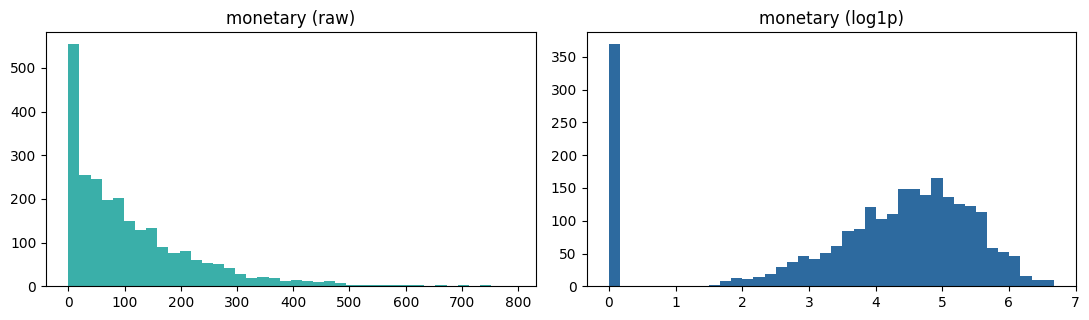

In [6]:
# -----------------------------------------------------------
# 🔹 2A. LOG-TRANSFORM A RIGHT-SKEWED COLUMN
# -----------------------------------------------------------
# EDA showed 'monetary' (total spend) is right-skewed. log1p compresses
# the long tail so big spenders don't dominate the model.
df['monetary_log'] = np.log1p(df['monetary'])   # log1p handles 0 safely
print('skew before:', round(df['monetary'].skew(), 2))
print('skew after :', round(df['monetary_log'].skew(), 2))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.3))
ax[0].hist(df['monetary'], bins=40, color='#3AAFA9'); ax[0].set_title('monetary (raw)')
ax[1].hist(df['monetary_log'], bins=40, color='#2D6A9F'); ax[1].set_title('monetary (log1p)')
plt.tight_layout(); plt.show()

In [ ]:
#LAB EXERCISE 2 — Tame another skewed feature
#Check the skew of avg_order_value.
#Create aov_log = log1p(avg_order_value) (fill missing with 0 first).
#Print the skew before and after and confirm it dropped toward 0.

In [7]:
# -----------------------------------------------------------
# LAB EXERCISE 2 — Tame another skewed feature
# -----------------------------------------------------------

# 1. Fill missing values in avg_order_value with 0
# (Customers with no orders have NaN average order value)

df['avg_order_value'] = df['avg_order_value'].fillna(0)

# Calculate and print the skew before transformation

skew_before = df['avg_order_value'].skew()

print("Skew before log transformation:",
      round(skew_before, 2))

# -----------------------------------------------------------
# 2. Apply log transformation using log1p()
# log1p(x) = log(1 + x), which safely handles zeros
# -----------------------------------------------------------

df['aov_log'] = np.log1p(df['avg_order_value'])

# -----------------------------------------------------------
# 3. Calculate and print the skew after transformation
# -----------------------------------------------------------

skew_after = df['aov_log'].skew()

print("Skew after log transformation :",
      round(skew_after, 2))

# -----------------------------------------------------------
# Compare the two skew values
# -----------------------------------------------------------

print("\nSkew reduced from",
      round(skew_before, 2),
      "to",
      round(skew_after, 2))

Skew before log transformation: 2.72
Skew after log transformation : -1.42

Skew reduced from 2.72 to -1.42


In [ ]:
#3. Binning — continuous → groups

In [8]:
# -----------------------------------------------------------
# 🔹 3A. BUCKET AGE INTO LIFE-STAGE GROUPS
# -----------------------------------------------------------
df['age_group'] = pd.cut(df['age'], bins=[0, 25, 40, 60, 200],
                         labels=['<25', '25-39', '40-59', '60+'])
print(df['age_group'].value_counts(dropna=False))

age_group
25-39    1025
40-59     872
<25       355
NaN       175
60+        73
Name: count, dtype: int64


In [ ]:
#LAB EXERCISE 3 — Recency buckets
#Turn recency_days into an interpretable signal for the business.
#Use pd.cut to bucket recency_days into ['active','lapsing','dormant'] (choose sensible day thresholds, e.g. 0–30, 30–90, 90+).
#Print the counts per bucket.
#Cross-tab the bucket against is_churned to see if 'dormant' really churns more.

In [9]:
# -----------------------------------------------------------
# LAB EXERCISE 3 — Recency Buckets
# -----------------------------------------------------------

# 1. Bucket recency_days into Active, Lapsing, Dormant

df['recency_bucket'] = pd.cut(
    df['recency_days'],
    bins=[-1, 30, 90, 100000],
    labels=['active', 'lapsing', 'dormant']
)

# -----------------------------------------------------------
# 2. Print the number of customers in each bucket
# -----------------------------------------------------------

print("Customers in each recency bucket:\n")

print(df['recency_bucket'].value_counts(dropna=False))

# -----------------------------------------------------------
# 3. Cross-tab recency bucket vs churn status
# normalize='index' gives row-wise proportions
# -----------------------------------------------------------

print("\nChurn rate by recency bucket:\n")

print(
    pd.crosstab(
        df['recency_bucket'],
        df['is_churned'],
        normalize='index'
    ).round(3)
)

Customers in each recency bucket:

recency_bucket
dormant    1507
lapsing     531
active      462
Name: count, dtype: int64

Churn rate by recency bucket:

is_churned          0      1
recency_bucket              
active          0.933  0.067
lapsing         0.947  0.053
dormant         0.764  0.236


In [ ]:
#4. Ratios & interaction features

In [10]:
# -----------------------------------------------------------
# 🔹 4A. RATIOS THAT EXPOSE BEHAVIOUR  (mind divide-by-zero!)
# -----------------------------------------------------------
# tickets per order: a dissatisfaction signal, normalised by activity
df['tickets_per_order'] = df['support_tickets'] / df['frequency'].replace(0, np.nan)
df['tickets_per_order'] = df['tickets_per_order'].fillna(0)   # 0 orders -> 0

# spend per category: concentration of spend
df['spend_per_category'] = df['monetary'] / df['n_categories'].replace(0, np.nan)
df['spend_per_category'] = df['spend_per_category'].fillna(0)
print(df[['support_tickets', 'frequency', 'tickets_per_order',
          'monetary', 'n_categories', 'spend_per_category']].head())

   support_tickets  frequency  tickets_per_order  monetary  n_categories  \
0                2        0.0                0.0      0.00           0.0   
1                1        0.0                0.0      0.00           0.0   
2                1        1.0                1.0     39.17           1.0   
3                1        1.0                1.0      2.74           1.0   
4                0        4.0                0.0    133.80           3.0   

   spend_per_category  
0                0.00  
1                0.00  
2               39.17  
3                2.74  
4               44.60  


In [ ]:
#LAB EXERCISE 4 — Engagement ratio
#Build orders_per_month = frequency ÷ (tenure in months). Compute tenure months as (SNAPSHOT - signup_date).dt.days / 30, and guard against zero/NaN.
#Fill any missing/infinite values with 0.
#Show the new column for the 5 highest-frequency customers.

In [ ]:
#5. Datetime features

In [11]:

# -----------------------------------------------------------
# 🔹 5A. UNLOCK THE DATE COLUMNS
# -----------------------------------------------------------
df['tenure_days'] = (SNAPSHOT - df['signup_date']).dt.days   # how long a customer
df['signup_month'] = df['signup_date'].dt.month
df['signup_dow'] = df['signup_date'].dt.dayofweek            # 0=Mon
df['signup_is_weekend'] = (df['signup_dow'] >= 5).astype(int)
# cyclical encoding so Dec(12) and Jan(1) are 'close', not far apart
df['month_sin'] = np.sin(2 * np.pi * df['signup_month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['signup_month'] / 12)
df[['signup_date', 'tenure_days', 'signup_month',
    'signup_dow', 'signup_is_weekend', 'month_sin', 'month_cos']].head()


,signup_date,tenure_days,signup_month,signup_dow,signup_is_weekend,month_sin,month_cos
0,2021-04-19,1168,4,0,0,8.660254e-01,-5.000000e-01
1,2023-07-31,335,7,0,0,-5.000000e-01,-8.660254e-01
2,2023-03-07,481,3,1,0,1.000000e+00,6.123234e-17
3,2022-06-18,743,6,5,1,1.224647e-16,-1.000000e+00
4,2022-06-11,750,6,5,1,1.224647e-16,-1.000000e+00


In [ ]:
#LAB EXERCISE 5 — Days since first order
#Build days_since_first_order = days from first_order_date to the SNAPSHOT.
#Some customers never ordered (first_order_date is NaT) → fill those with 0.
#Show the new column alongside first_order_date for a few rows.

In [17]:
# -----------------------------------------------------------
# 1. Calculate days since first order
# -----------------------------------------------------------

df['days_since_first_order'] = (
    SNAPSHOT - df['first_order_date']
).dt.days

# -----------------------------------------------------------
# 2. Fill NaN values with 0
# -----------------------------------------------------------

df['days_since_first_order'] = (
    df['days_since_first_order']
    .fillna(0)
)

# -----------------------------------------------------------
# 3. Display sample rows
# -----------------------------------------------------------

print(
    df[['first_order_date', 'days_since_first_order']].head()
)

  first_order_date  days_since_first_order
0              NaT                     0.0
1              NaT                     0.0
2       2023-05-22                   405.0
3       2022-07-02                   729.0
4       2022-09-18                   651.0


In [ ]:
#6. Encoding categorical features

In [12]:
# -----------------------------------------------------------
# 🔹 6A. ONE-HOT THE LOW-CARDINALITY COLUMNS
# -----------------------------------------------------------
df = pd.get_dummies(df, columns=['plan', 'device', 'payment_method'],
                    drop_first=False, dtype=int)
print('columns after one-hot:', df.shape[1])
print([c for c in df.columns if c.startswith(('plan_', 'device_'))])


columns after one-hot: 40
['plan_Basic', 'plan_Premium', 'plan_Standard', 'device_Desktop', 'device_Mobile', 'device_Tablet']


In [13]:
# -----------------------------------------------------------
# 🔹 6B. FREQUENCY-ENCODE THE HIGH-CARDINALITY 'city'
# -----------------------------------------------------------
# one-hot on 17 cities would add 17 sparse columns; frequency encoding
# keeps it to ONE numeric column = how common each city is.
freq = df['city'].value_counts(normalize=True)
df['city_freq'] = df['city'].map(freq).fillna(0)
print(df[['city', 'city_freq']].drop_duplicates().head(8))

          city  city_freq
0      Chennai   0.103265
1    Hyderabad   0.130612
2         Pune   0.082857
4       Mumbai   0.169796
5        Delhi   0.165306
10   Bengaluru   0.159184
13       Patna   0.013469
14  Coimbatore   0.016735


In [18]:
#LAB EXERCISE 6 — Encode gender safely
#gender has missing values, so handle them before encoding.
#Fill missing gender with the string 'Unknown'.
#One-hot encode gender with pd.get_dummies (dtype=int).
#Print the new gender columns.

In [19]:
# -----------------------------------------------------------
# 1. Fill missing gender values
# -----------------------------------------------------------

df['gender'] = df['gender'].fillna('Unknown')

# -----------------------------------------------------------
# 2. One-hot encode gender
# -----------------------------------------------------------

df = pd.get_dummies(
    df,
    columns=['gender'],
    dtype=int
)

# -----------------------------------------------------------
# 3. Print new gender columns
# -----------------------------------------------------------

print(
    [col for col in df.columns if col.startswith('gender_')]
)

['gender_F', 'gender_M', 'gender_Other', 'gender_Unknown']


In [ ]:
#7. Rare categories & high cardinality

In [14]:
# -----------------------------------------------------------
# 🔹 7A. BUCKET RARE CITIES INTO 'Other'
# -----------------------------------------------------------
top_cities = df['city'].value_counts().head(7).index   # keep the 7 biggest
df['city_grouped'] = df['city'].where(df['city'].isin(top_cities), 'Other')
print('before:', df['city'].nunique(), 'cities')
print('after :', df['city_grouped'].nunique(), 'categories')
print(df['city_grouped'].value_counts())

before: 17 cities
after : 8 categories
city_grouped
Mumbai       416
Delhi        405
Bengaluru    390
Other        373
Hyderabad    320
Chennai      253
Pune         203
Kolkata      140
Name: count, dtype: int64


In [20]:
# LAB EXERCISE 7 — One-hot the grouped city
#One-hot encode city_grouped (now only ~8 categories) with pd.get_dummies.
##Print how many new columns that produced.
#In a comment, explain why grouping first is better than one-hot on all 17 raw cities.

In [ ]:
#8. Domain-driven features

In [15]:
# -----------------------------------------------------------
# 🔹 8A. ENCODE BUSINESS KNOWLEDGE AS FEATURES
# -----------------------------------------------------------
# a 'dormant' flag: no orders, or very stale
df['is_dormant'] = ((df['frequency'] == 0) | (df['recency_days'] > 180)).astype(int)
# a simple RFM score: rank each of R, F, M into 1-4 and combine
df['R_score'] = pd.qcut(-df['recency_days'].rank(method='first'), 4, labels=[1,2,3,4]).astype(int)
df['F_score'] = pd.qcut(df['frequency'].rank(method='first'), 4, labels=[1,2,3,4]).astype(int)
df['M_score'] = pd.qcut(df['monetary'].rank(method='first'), 4, labels=[1,2,3,4]).astype(int)
df['rfm_score'] = df['R_score'] + df['F_score'] + df['M_score']   # 3..12
print(df[['recency_days', 'frequency', 'monetary', 'rfm_score', 'is_dormant']].head())
print('\nMean churn by RFM score:')
print(df.groupby('rfm_score')['is_churned'].mean().round(2))

   recency_days  frequency  monetary  rfm_score  is_dormant
0        9999.0        0.0      0.00          3           1
1        9999.0        0.0      0.00          3           1
2         405.0        1.0     39.17          5           1
3         729.0        1.0      2.74          3           1
4          15.0        4.0    133.80         10           0

Mean churn by RFM score:
rfm_score
3     0.58
4     0.19
5     0.13
6     0.09
7     0.07
8     0.10
9     0.08
10    0.08
11    0.04
12    0.05
Name: is_churned, dtype: float64


In [ ]:
#LAB EXERCISE 8 — Invent a feature for the business
#Build high_value = 1 when a customer is in the top 20% of monetary, else 0 (hint: compare to df['monetary'].quantile(0.8)).
#Compare the churn rate of high-value vs the rest with a groupby.
#In a comment, suggest one more domain feature you'd add and why.

In [23]:
# -----------------------------------------------------------
# LAB EXERCISE 8 — Invent a feature for the business
# -----------------------------------------------------------

# 1. Create a high_value flag
# Customers in the top 20% of monetary spending are marked as 1

threshold = df['monetary'].quantile(0.80)

df['high_value'] = (df['monetary'] >= threshold).astype(int)

# -----------------------------------------------------------
# 2. Compare churn rate of high-value vs other customers
# -----------------------------------------------------------

print("Churn Rate by High-Value Customer:\n")

print(
    df.groupby('high_value')['is_churned']
      .mean()
      .round(3)
)

# -----------------------------------------------------------
# (Optional) Show customer counts in each group
# -----------------------------------------------------------

print("\nNumber of Customers:\n")

print(
    df['high_value'].value_counts()
)

# -----------------------------------------------------------
# 3. Comment
# -----------------------------------------------------------

# Another domain feature I would add is:
#
# "days_since_last_support_ticket"
#
# Customers who recently raised multiple support tickets and
# have not purchased again may have a higher probability of
# churning. This feature could capture customer dissatisfaction
# and improve churn prediction accuracy.

Churn Rate by High-Value Customer:

high_value
0    0.194
1    0.052
Name: is_churned, dtype: float64

Number of Customers:

high_value
0    2000
1     500
Name: count, dtype: int64


In [ ]:
#9. Assemble the feature matrix — and check for leakage
#Leakage check: a feature must only use information available at prediction time. Drop IDs, raw dates and the target itself; keep engineered numerics.

In [16]:
# -----------------------------------------------------------
# 🔹 9A. BUILD X (features) AND y (target)
# -----------------------------------------------------------
drop_cols = ['customer_id', 'signup_date', 'first_order_date', 'last_order_date',
             'city', 'gender', 'age_group', 'city_grouped', 'is_churned']
X = df.drop(columns=[c for c in drop_cols if c in df.columns])
X = X.select_dtypes(include='number')   # keep numeric features only
y = df['is_churned']
print('Feature matrix:', X.shape)
print('All numeric? ', X.select_dtypes(exclude='number').empty)
print('Any missing? ', int(X.isna().sum().sum()))
print('\nEngineered features include:')
print([c for c in X.columns if c in ('monetary_log','recency_days','rfm_score',
       'tickets_per_order','tenure_days','city_freq','is_dormant')])

Feature matrix: (2500, 37)
All numeric?  True
Any missing?  980

Engineered features include:
['recency_days', 'monetary_log', 'tickets_per_order', 'tenure_days', 'city_freq', 'is_dormant', 'rfm_score']


In [ ]:
#LAB EXERCISE 9 — Sanity-check & sniff for leakage
#Fill any remaining missing values in X (e.g. age) with the column median.
#Print the correlation of each feature with y, sorted — the strongest are your best predictors.
#In a comment, name one feature that would be leakage if it existed (a value you could only know after a customer churned).

In [24]:
# -----------------------------------------------------------
# LAB EXERCISE 9 — Sanity-check & Sniff for Leakage
# -----------------------------------------------------------

# 1. Fill remaining missing values with the median

X = X.fillna(X.median(numeric_only=True))

print("Remaining Missing Values:")

print(X.isna().sum().sum())

# -----------------------------------------------------------
# 2. Correlation of each feature with the target (y)
# -----------------------------------------------------------

corr = (
    X.assign(churn=y)
     .corr()['churn']
     .drop('churn')
     .sort_values(ascending=False)
)

print("\nFeature Correlation with Churn:\n")

print(corr)

# -----------------------------------------------------------
# (Optional) Top 10 strongest predictors
# -----------------------------------------------------------

print("\nTop 10 Strongest Predictors:\n")

print(corr.head(10))

# -----------------------------------------------------------
# 3. Comment
# -----------------------------------------------------------

# A feature that would cause data leakage is:
#
# "account_closed_date" or "churn_date"
#
# These values are only known after a customer has already
# churned. Using them during model training would leak future
# information into the model and produce unrealistically high
# prediction accuracy.

Remaining Missing Values:
0

Feature Correlation with Churn:

recency_days                 0.515644
is_dormant                   0.310526
support_tickets              0.068880
tenure_days                  0.038022
signup_dow                   0.024051
payment_method_Card          0.020432
plan_Standard                0.015577
city_freq                    0.015418
email_opt_in                 0.011145
device_Mobile                0.010228
month_sin                    0.007953
month_cos                    0.006207
payment_method_UPI           0.005824
signup_is_weekend            0.004310
device_Tablet               -0.001560
plan_Basic                  -0.008266
plan_Premium                -0.009152
device_Desktop              -0.009811
age                         -0.010510
payment_method_NetBanking   -0.013934
signup_month                -0.018184
payment_method_Wallet       -0.024611
tickets_per_order           -0.048281
avg_days_between_orders     -0.055191
total_spend               